In [29]:
import kagglehub, glob, os
import pandas as pd 
import matplotlib.pylab as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
sns.set_theme()

In [17]:
path = kagglehub.dataset_download('mdwiraputradananjaya/ssh-anomaly-dataset')
print(path)

/Users/amar/.cache/kagglehub/datasets/mdwiraputradananjaya/ssh-anomaly-dataset/versions/1


In [20]:
df = pd.read_csv(os.path.join(path, "ssh_anomaly_dataset.csv"))
print(f"\nHead data")
display(df.head(10))
print(f"\nTail Data")
display(df.tail(10))
print(df.info())


Head data


,timestamp,source_ip,username,event_type,status,label,detail
0,2025-06-15 09:00:00.000000,192.168.0.46,john_doe,Accepted password,success,normal,NaN
1,2025-06-15 09:00:01.673608,192.168.0.46,john_doe,Command executed,pwd,normal,NaN
2,2025-06-15 09:01:05.018929,192.168.0.37,analyst_user,Accepted password,success,normal,NaN
3,2025-06-15 09:01:09.198906,192.168.0.37,analyst_user,Command executed,uptime,normal,NaN
4,2025-06-15 09:04:30.880364,192.168.0.46,john_doe,Disconnected,normal_logout,normal,NaN
5,2025-06-15 09:04:39.767203,192.168.0.40,jane_smith,Accepted password,success,normal,NaN
6,2025-06-15 09:04:42.494414,192.168.0.40,jane_smith,Command executed,df -h,normal,NaN
7,2025-06-15 09:05:58.737742,192.168.0.37,analyst_user,Disconnected,normal_logout,normal,NaN
8,2025-06-15 09:07:31.377120,192.168.0.40,jane_smith,Disconnected,normal_logout,normal,NaN
9,2025-06-15 09:09:27.448609,192.168.0.23,analyst_user,Failed password,auth_fail_normal_typo,normal,NaN



Tail Data


,timestamp,source_ip,username,event_type,status,label,detail
41815,2025-06-18 08:45:07.143100,192.168.0.12,john_doe,Command executed,whoami,normal,NaN
41816,2025-06-18 08:46:47.943138,192.168.0.27,dev_user,Disconnected,normal_logout,normal,NaN
41817,2025-06-18 08:47:56.638732,192.168.0.12,john_doe,Disconnected,normal_logout,normal,NaN
41818,2025-06-18 08:49:17.249737,192.168.0.42,jane_smith,Accepted password,success,normal,NaN
41819,2025-06-18 08:53:25.058318,192.168.0.42,jane_smith,Disconnected,normal_logout,normal,NaN
41820,2025-06-18 08:53:38.678430,192.168.0.47,jane_smith,Accepted password,success,normal,NaN
41821,2025-06-18 08:53:42.223648,192.168.0.47,jane_smith,Command executed,df -h,normal,NaN
41822,2025-06-18 08:57:16.668250,192.168.0.47,jane_smith,Disconnected,normal_logout,normal,NaN
41823,2025-06-18 08:57:45.616961,192.168.0.28,dev_user,Accepted password,success,normal,NaN
41824,2025-06-18 08:59:51.066306,192.168.0.28,dev_user,Disconnected,normal_logout,normal,NaN


<class 'pandas.DataFrame'>
RangeIndex: 41825 entries, 0 to 41824
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   timestamp   41825 non-null  str  
 1   source_ip   41825 non-null  str  
 2   username    41825 non-null  str  
 3   event_type  41825 non-null  str  
 4   status      41825 non-null  str  
 5   label       41825 non-null  str  
 6   detail      2 non-null      str  
dtypes: str(7)
memory usage: 2.2 MB
None


# Pre-Processing Steps

In [23]:
# Just to non-null values, so dropped the column altogether
# df = df.drop(columns=["detail"])
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 41825 entries, 0 to 41824
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   timestamp   41825 non-null  str  
 1   source_ip   41825 non-null  str  
 2   username    41825 non-null  str  
 3   event_type  41825 non-null  str  
 4   status      41825 non-null  str  
 5   label       41825 non-null  str  
dtypes: str(6)
memory usage: 1.9 MB


None

In [25]:
# Parse timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index('timestamp').sort_index()

df["label_bin"] = df["label"].apply(lambda x: 0 if x.strip().lower() == "normal" else 1) 
print(df.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 41825 entries, 2025-06-15 09:00:00 to 2025-06-18 08:59:51.066306
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   source_ip   41825 non-null  str  
 1   username    41825 non-null  str  
 2   event_type  41825 non-null  str  
 3   status      41825 non-null  str  
 4   label       41825 non-null  str  
 5   label_bin   41825 non-null  int64
dtypes: int64(1), str(5)
memory usage: 2.2 MB
None


In [26]:
df['hour']         = df.index.hour
df['day_of_week']  = df.index.day_name()
df['weekday']      = df.index.weekday          # 0=Mon ... 6=Sun
df['date']         = df.index.date
df['hour_of_day']  = df.index.hour
df['is_weekend']   = df.index.weekday >= 5
df['minute_of_day']= df.index.hour*60 + df.index.minute

events_per_minutes = df.resample("1min").count()

In [28]:
display(df.head(10))
display(df.tail(10))

,source_ip,username,event_type,status,label,label_bin,hour,day_of_week,weekday,date,hour_of_day,is_weekend,minute_of_day
timestamp,,,,,,,,,,,,,
2025-06-15 09:00:00.000000,192.168.0.46,john_doe,Accepted password,success,normal,0,9,Sunday,6,2025-06-15,9,True,540
2025-06-15 09:00:01.673608,192.168.0.46,john_doe,Command executed,pwd,normal,0,9,Sunday,6,2025-06-15,9,True,540
2025-06-15 09:01:05.018929,192.168.0.37,analyst_user,Accepted password,success,normal,0,9,Sunday,6,2025-06-15,9,True,541
2025-06-15 09:01:09.198906,192.168.0.37,analyst_user,Command executed,uptime,normal,0,9,Sunday,6,2025-06-15,9,True,541
2025-06-15 09:04:30.880364,192.168.0.46,john_doe,Disconnected,normal_logout,normal,0,9,Sunday,6,2025-06-15,9,True,544
2025-06-15 09:04:39.767203,192.168.0.40,jane_smith,Accepted password,success,normal,0,9,Sunday,6,2025-06-15,9,True,544
2025-06-15 09:04:42.494414,192.168.0.40,jane_smith,Command executed,df -h,normal,0,9,Sunday,6,2025-06-15,9,True,544
2025-06-15 09:05:58.737742,192.168.0.37,analyst_user,Disconnected,normal_logout,normal,0,9,Sunday,6,2025-06-15,9,True,545
2025-06-15 09:07:31.377120,192.168.0.40,jane_smith,Disconnected,normal_logout,normal,0,9,Sunday,6,2025-06-15,9,True,547


,source_ip,username,event_type,status,label,label_bin,hour,day_of_week,weekday,date,hour_of_day,is_weekend,minute_of_day
timestamp,,,,,,,,,,,,,
2025-06-18 08:45:07.143100,192.168.0.12,john_doe,Command executed,whoami,normal,0,8,Wednesday,2,2025-06-18,8,False,525
2025-06-18 08:46:47.943138,192.168.0.27,dev_user,Disconnected,normal_logout,normal,0,8,Wednesday,2,2025-06-18,8,False,526
2025-06-18 08:47:56.638732,192.168.0.12,john_doe,Disconnected,normal_logout,normal,0,8,Wednesday,2,2025-06-18,8,False,527
2025-06-18 08:49:17.249737,192.168.0.42,jane_smith,Accepted password,success,normal,0,8,Wednesday,2,2025-06-18,8,False,529
2025-06-18 08:53:25.058318,192.168.0.42,jane_smith,Disconnected,normal_logout,normal,0,8,Wednesday,2,2025-06-18,8,False,533
2025-06-18 08:53:38.678430,192.168.0.47,jane_smith,Accepted password,success,normal,0,8,Wednesday,2,2025-06-18,8,False,533
2025-06-18 08:53:42.223648,192.168.0.47,jane_smith,Command executed,df -h,normal,0,8,Wednesday,2,2025-06-18,8,False,533
2025-06-18 08:57:16.668250,192.168.0.47,jane_smith,Disconnected,normal_logout,normal,0,8,Wednesday,2,2025-06-18,8,False,537
2025-06-18 08:57:45.616961,192.168.0.28,dev_user,Accepted password,success,normal,0,8,Wednesday,2,2025-06-18,8,False,537


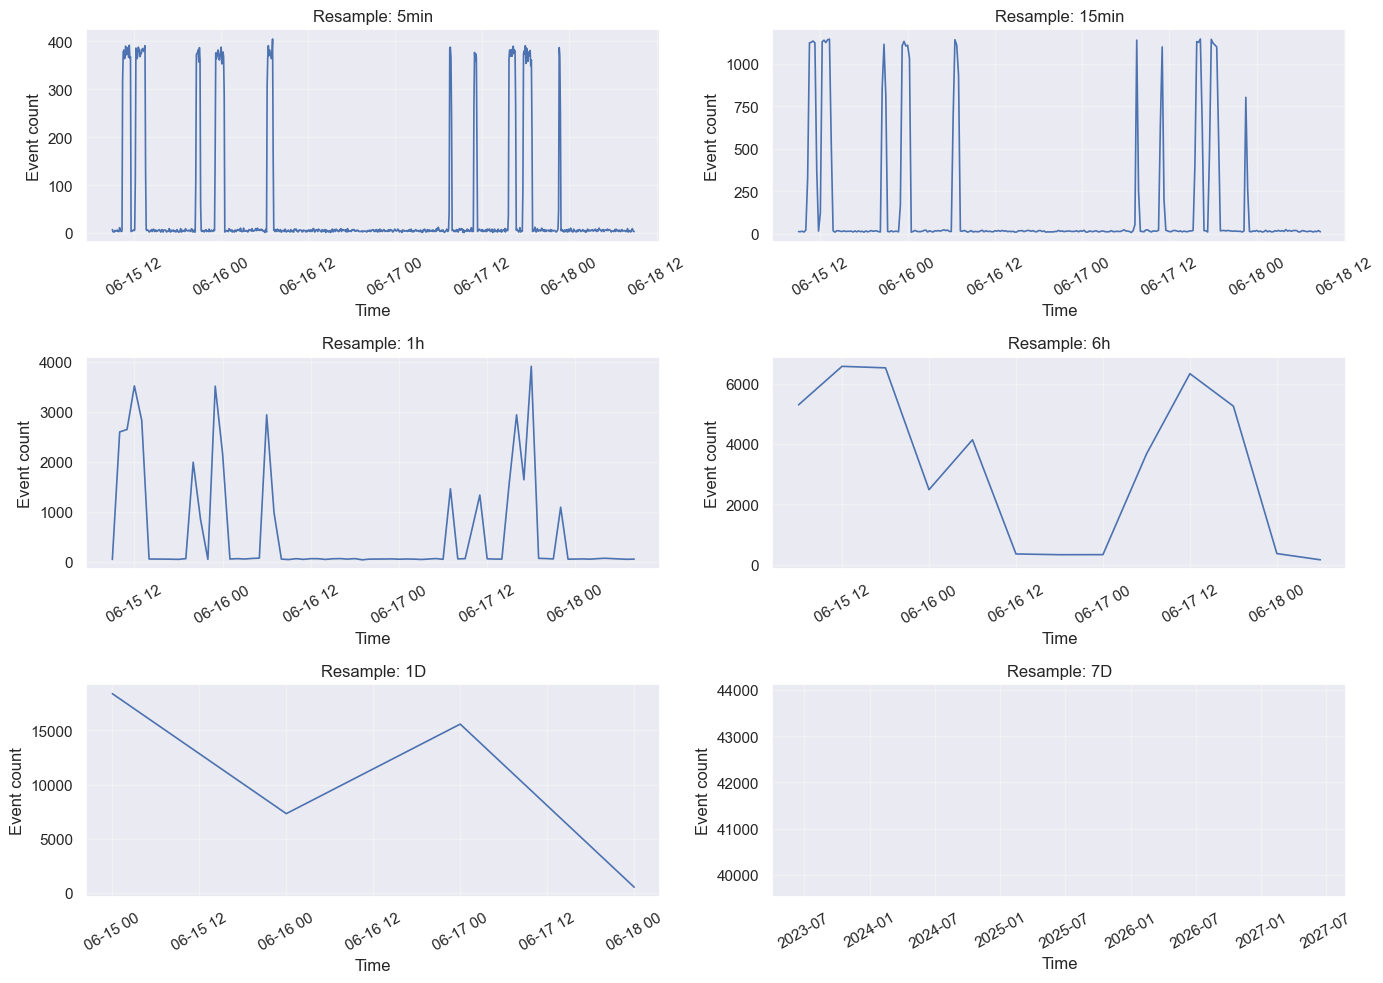

In [47]:
freqs = ['5min', '15min', '1h', '6h', '1D', '7D']
counts = []
for f in freqs:
    counts.append(df.resample(f).size())

fig, ax = plt.subplots(3, 2, figsize=(14, 10), sharex=False)

# flatten into 1D so that you don't have to deal with (x, y) format
ax = ax.ravel()

for i, (f, s) in enumerate(zip(freqs, counts)):
    ax[i].plot(s.index, s.values, linewidth=1.2)
    ax[i].set_title(f"Resample: {f}")
    ax[i].set_xlabel("Time")
    ax[i].set_ylabel("Event count")
    ax[i].tick_params(axis="x", rotation=30)
    ax[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# from statsmodels.tsa.seasonal import seasonal_decompose

# fig, ax = plt.subplots(3, 1, figsize=(14, 10))

# for i in range(3): 
#     sns.histplot(data=)

7
3
2
2
5
5
4
4
6
4
3
3
11
6
4
3
4
320
378
382
